## 訓練データの作成

In [177]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.font_manager
import numpy as np
import random
import matplotlib.pyplot as plt
import cv2

font_pathes = [
    "/System/Library/Fonts/Supplemental/Arial.ttf",
    "/System/Library/Fonts/Supplemental/Times New Roman.ttf",
    # "/System/Library/Fonts/Supplemental/Trattatello.ttf",
    # "/Users/yuonoda/Library/Fonts/NotoSans-BoldItalic.ttf",
    # "/Users/yuonoda/Library/Fonts/NotoSans-Bold.ttf",
    # "/Users/yuonoda/Library/Fonts/NotoSans-Italic.ttf",
]
print("variation patterns=", len(font_pathes))

# 利用するフォントサイズをパターン指定
font_sizes = range(30, 40, 1)
# font_sizes = [50]
print("sizes patterns =", len(font_sizes))

# 生成した画像とラベルを格納するリスト
images = []
labels = []

# 各フォントに対して
NOISE_PATTERN_NUM = 50
for font_path in font_pathes:

    # 各フォントサイズに対して
    for font_size in font_sizes:
        try:
            # フォントオブジェクトを作成
            font = ImageFont.truetype(font_path, size=font_size)
        except IOError:
            continue  # エラーが起きた場合、このフォントはスキップします

        # 数字0-9を描画
        for number in range(10):
            
            # 0の場合、背景画像を使う
            if number == 0:
                # リサイズ、グレースケール
                # image = Image.new('RGB', (100, 100))
                image = Image.new('L', (60, 60), 255)
                # image = image.resize((60, 60))
                np_image = np.array(image)
                # np_image = cv2.cvtColor(np_image, cv2.COLOR_RGB2GRAY)

                # 画像とラベルを保存
                images.append(np_image)
                labels.append(number)
                continue

            # 1-9のときは、ノイズを加えてデータを増やす
            for _ in range(NOISE_PATTERN_NUM):

                # 新しい画像オブジェクトを生成
                # image = Image.new('RGB', (100, 100))
                image = Image.new('L', (60, 60), 255)
                draw = ImageDraw.Draw(image)
                # draw = ImageDraw.Draw(image.copy())

                # # 位置ノイズを作成
                x_noise = random.randint(-10, 10)
                y_noise = random.randint(-10, 10)
                # x_noise = 0
                # y_noise = 0

                # 数字を中央付近に描画
                text = str(number)
                text_width, text_height = draw.textsize(text, font=font)
                x = (image.width - text_width) // 2 + x_noise
                y = (image.height - text_height) // 2 + y_noise
                draw.text((x, y), text, font=font, fill=0)

                #リサイズ
                size = random.randint(30, 60)
                image = image.resize((size, size))
                image = image.resize((60, 60),Image.ANTIALIAS)

                # グレースケールに変換
                np_image = np.array(image)
                # np_image = cv2.cvtColor(np_image, cv2.COLOR_RGB2GRAY)

                # 二値化
                _, np_image = cv2.threshold(np_image, 127, 255, cv2.THRESH_BINARY)
                
                # 画像とラベルを保存
                images.append(np_image)
                labels.append(number)

# イメージをリサイズ
resized_images = []
for img in images:
    resized = cv2.resize(img, (30,30))
    resized_images.append(resized)
images = resized_images
print("total images =", len(images))

variation patterns= 2
sizes patterns = 10


/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_2790/3601623273.py:73: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_2790/3601623273.py:81: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  image = image.resize((60, 60),Image.ANTIALIAS)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_2790/3601623273.py:73: DeprecationWarning: textsize is deprecated and will be removed in Pillow 10 (2023-07-01). Use textbbox or textlength instead.
  text_width, text_height = draw.textsize(text, font=font)
/var/folders/zn/fnw8r7yx13lf69f4vw157gjr0000gn/T/ipykernel_2790/3601623273.py:81: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LA

total images = 9020


In [17]:
np.unique(images[0])

array([255], dtype=uint8)

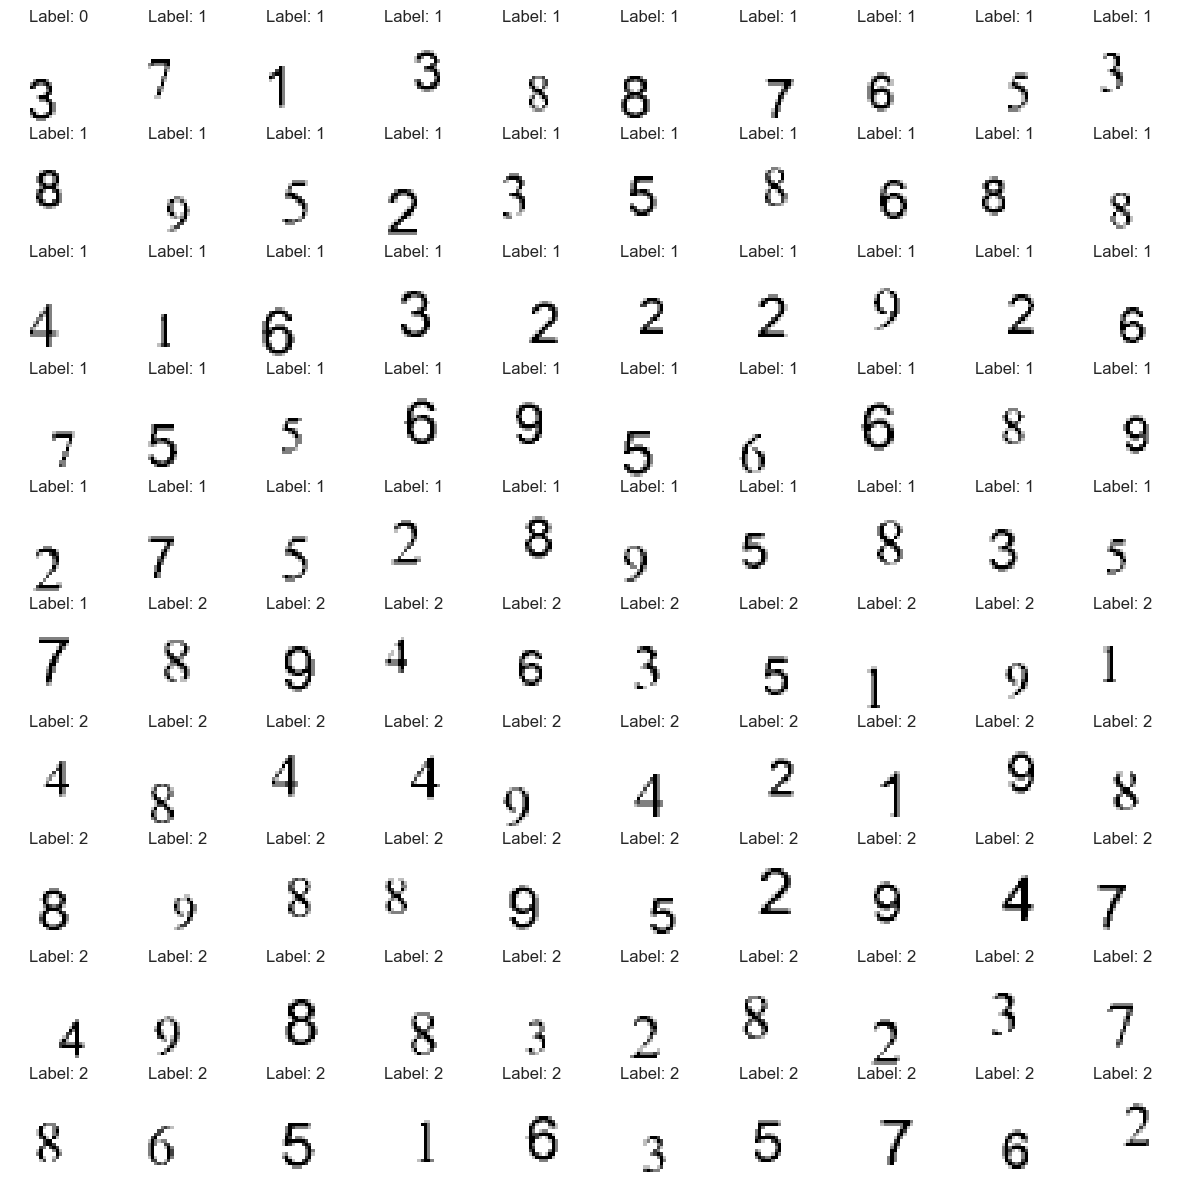

In [178]:
import matplotlib.pyplot as plt
import math

# イメージの合計枚数を取得
# images_to_show =random.sample(final_images, 100) # ランダムに100個取得
images_to_show =random.sample(images, 100) # ランダムに100個取得
# images_to_show = images
total_images = len(images_to_show)

# グリッドのサイズを計算 (例: 20x10)
cols = 10   
rows = math.ceil(total_images / cols)  # 必要な行数を計算

# 画像とラベルを表示
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
for idx, ax in enumerate(axes.flatten()):
    if idx < total_images:
        ax.imshow(images_to_show[idx], cmap='gray')
        ax.set_title(f"Label: {labels[idx]}")
    ax.axis('off')  # 軸を非表示に
plt.show()

In [179]:
# numpy配列に変換
images = np.array(images)
labels = np.array(labels)

# .npz形式で保存
x_reshaped = images.reshape((images.shape[0], -1))
np.savez("../images_and_labels.npz", x=x_reshaped, y=labels)


## 画像マスの抽出

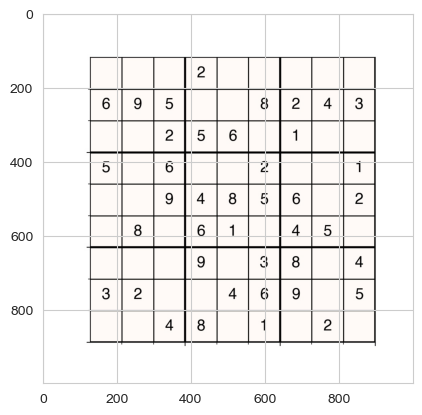

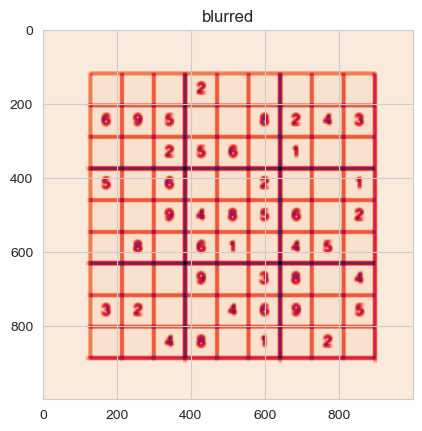

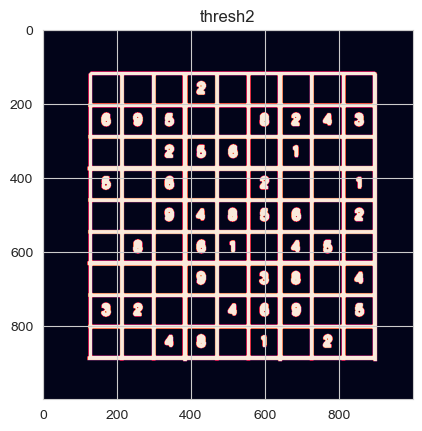

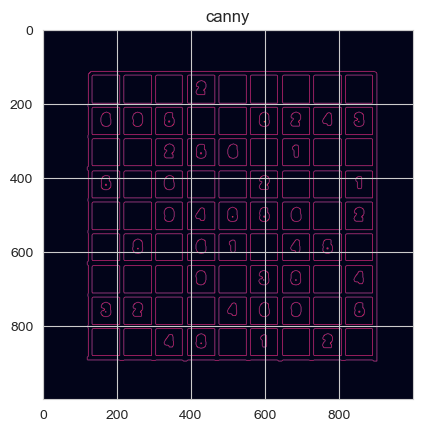

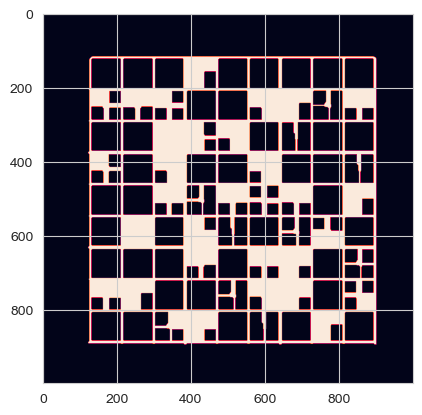

In [198]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
filepath = "../data/level1/sudoku_028"
imgname = filepath + ".jpg"
img = cv2.imread(imgname, cv2.IMREAD_COLOR)
if img is None:
    raise IOError("Faileld to load image: {:s}".format(filepath))
plt.imshow(img)
plt.show()

# 白黒データに変換
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ぼかし
blurred = cv2.GaussianBlur(gray, (11, 11), 90)
plt.imshow(blurred)
plt.title("blurred")
plt.show()

# # 大津の二値化
# _, thresh = cv2.threshold(blurred,0, 255, cv2.THRESH_OTSU )
# plt.imshow(thresh)
# plt.title("thresh")
# plt.show()

# 二値化
_, thresh2 = cv2.threshold(blurred, 220, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh2)
plt.title("thresh2")
plt.show()

# Canny法でエッジ検出
canny = cv2.Canny(thresh2, 127, 200)
plt.imshow(canny)
plt.title("canny")
plt.show()

# エッジ統合
res = canny.copy()
kerneal_size = 25
res = cv2.dilate(canny, np.ones((kerneal_size, kerneal_size)))
erode_kernel_size = 30
res = cv2.erode(res, np.ones((erode_kernel_size, erode_kernel_size )))
binary = res.copy()
plt.imshow(binary)
plt.show()


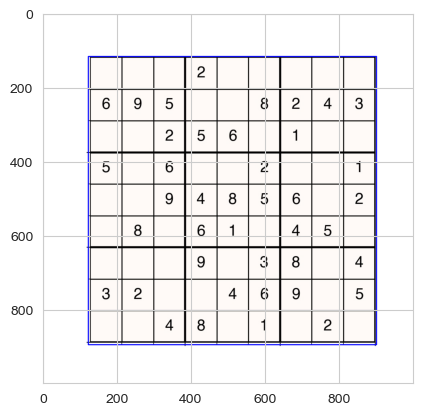

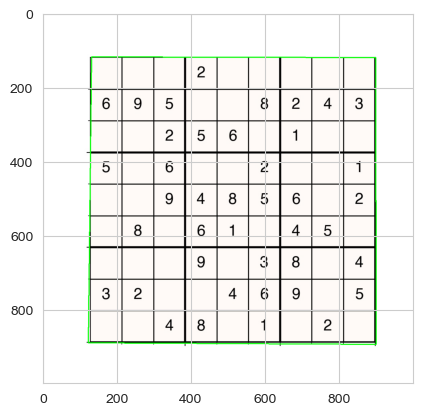

In [199]:
# 輪郭の外側を取得
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)
imgToShow = img.copy()
x, y, w, h = cv2.boundingRect(largest_contour)

# 境界矩形も描画する場合
cv2.rectangle(imgToShow, (x, y), (x+w, y+h), (0, 0, 255), 2)  # 赤色で2の太さで描画

# 画像を表示
plt.imshow(imgToShow)
plt.show()

# 輪郭の内側の座標を取得
imgToShow = img.copy()
mask = np.zeros_like(binary)
cv2.drawContours(mask, [largest_contour], -1, (255), thickness=cv2.FILLED)
inside_points = np.column_stack(np.where(mask == 255))

for contour in contours:
    # 輪郭を近似
    epsilon = 0.02 * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)

    # 近似した輪郭が四角形であるか確認
    if len(approx) == 4:
        cv2.drawContours(imgToShow, [approx], 0, (0, 255, 0), 2)  # 緑色で四角形の輪郭を描画
        x, y, w, h = cv2.boundingRect(approx)

# 画像を表示
plt.imshow(imgToShow)
plt.show()

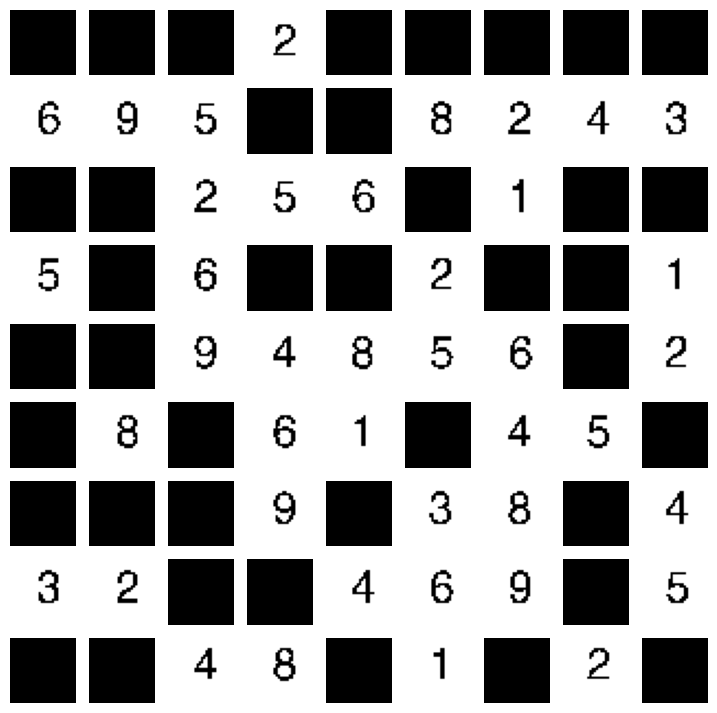

In [200]:

# 各マス目の画像を抽出し、リストに保存
cell_images = []
stepx = w // 9
stepy = h // 9
trim_size_x = stepx // 7
trim_size_y = stepy // 7
EMPTY_THRESHOLD = 200
for i in range(9):
    for j in range(9):
        cell = gray[y + i*stepy + trim_size_y : y + (i+1)*stepy - trim_size_y,
               x + j*stepx + trim_size_x : x + (j+1)*stepx - trim_size_x]

        # contours, _ = cv2.findContours(cell, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        # if contours:
        #     digit_contour = max(contours, key=cv2.contourArea)
        #     digit_x, digit_y, digit_w, digit_h = cv2.boundingRect(digit_contour)
        #     cv2.rectangle(cell, (digit_x, digit_y), (digit_x + digit_w, digit_y + digit_h), 0, 1) 

        resized_cell = cv2.resize(cell, (30, 30), interpolation=cv2.INTER_CUBIC)
        np_image = np.array(resized_cell)
        _, thresh = cv2.threshold(np_image, 127, 255, cv2.THRESH_BINARY)
        normalized = thresh / 255.0
        cell_images.append(normalized)


# 9x9のグリッドを作り、各セルに画像をプロット
fig, axs = plt.subplots(9, 9, figsize=(9, 9))
axs = axs.flatten()
for ax, cell in zip(axs, cell_images):
    ax.imshow(cell, cmap="gray") # BGRからRGBへ変換
    ax.axis('off')  # 軸の情報をオフにする

plt.show()

## 数字の学習

In [188]:
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split

# データ読み込み
# photos = np.load('../28px_10_new.npz')
photos = np.load('../images_and_labels.npz')
x = photos['x']
y = photos['y']
print("len(x)=", len(x))
print(x.shape)
print(y.shape)

# スケーリング
x = x / 255.0

# 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=1)

len(x)= 9020
(9020, 900)
(9020,)


In [22]:
from sklearn.neighbors import KNeighborsClassifier

# KNNで学習
n_neighbors = 20
clf = KNeighborsClassifier(n_neighbors=n_neighbors)
clf.fit(X_train, y_train)

# 訓練データでの精度を確認
acc_train = clf.score(X_train, y_train)
print("KNN CV: acc(train)={:.2f}".format(acc_train))

KNN CV: acc(train)=1.00%


In [187]:
from sklearn.linear_model import LogisticRegression

# ロジスティック回帰で学習
lr_params = {"tol": 1.0e-3, "max_iter": 5000, "solver": "lbfgs"}
clf = LogisticRegression(**lr_params)
clf.fit(X_train, y_train)

# 訓練データでの精度を確認
acc_train = clf.score(X_train, y_train)
print("LR CV: acc(train)={:.2f}".format(acc_train))

LR CV: acc(train)=0.48


In [189]:
# SVMで学習
clf = svm.SVC()
clf.fit(X_train, y_train)

# 訓練データでの精度を確認
acc_train = clf.score(X_train, y_train)
print("SVM CV: acc(train)={:.2f}".format(acc_train))

SVM CV: acc(train)=0.99


In [190]:
from sklearn import metrics

# 予測の実行
predicted = clf.predict(X_test)
print(f"Classification report for classifier {clf}:\n"
      f"{metrics.classification_report(y_test, predicted)}\n")


Classification report for classifier SVC():
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.96      1.00      0.98       220
           2       0.99      0.95      0.97       195
           3       0.93      0.94      0.93       204
           4       1.00      0.99      0.99       203
           5       0.95      0.93      0.94       199
           6       0.92      0.90      0.91       202
           7       0.95      0.99      0.97       202
           8       0.93      0.94      0.93       207
           9       0.97      0.96      0.97       170

    accuracy                           0.96      1804
   macro avg       0.96      0.96      0.96      1804
weighted avg       0.96      0.96      0.96      1804


In [185]:
import matplotlib.pyplot as plt
import seaborn as sns

# 混同行列の可視化
conf_mat = metrics.confusion_matrix(y_test, predicted)
plt.figure(figsize=(10, 10))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [1804, 81]

In [205]:
import gzip
import pickle
with gzip.open('clf_svm_1.pkl.gz', 'wb') as f:
    pickle.dump(clf, f)

In [204]:
# 再読み込みとテスト
with (gzip.open('clf_svm_1.pkl.gz', 'rb') as f):
    restored_clf = pickle.load(f)
acc_test = restored_clf.score(X_test, y_test)
print("CV: acc(test)={:.2f}%".format(acc_test))

CV: acc(test)=0.96%


# 数字予測

In [201]:
import numpy as np

# 予測
model_input = np.array(cell_images)
model_input_2d = model_input.reshape(model_input.shape[0], -1)# モデル入力を2次元に変換
predicted = clf.predict(model_input_2d)

textname = filepath + ".txt"
correct_labels = correct_labels = np.loadtxt(textname, dtype=int)
correct_labels_flat = correct_labels.flatten()

# Accuracyを計算して表示
accuracy = metrics.accuracy_score(correct_labels_flat, predicted)
print(f"Accuracy: {accuracy:.2f}")

print(metrics.classification_report(correct_labels_flat, predicted))

Accuracy: 0.98
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         6
           5       1.00      0.83      0.91         6
           6       0.75      1.00      0.86         6
           8       1.00      0.80      0.89         5
           9       1.00      1.00      1.00         4

    accuracy                           0.98        81
   macro avg       0.97      0.96      0.96        81
weighted avg       0.98      0.98      0.98        81


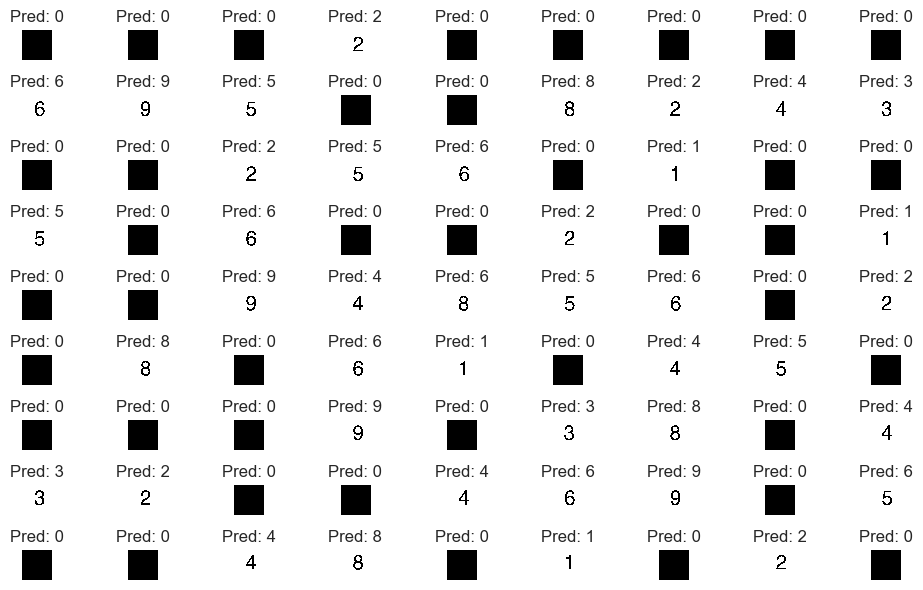

In [202]:
# 画像と予測結果を並べて表示します

# 行と列の数を設定
n_rows = 9
n_cols = 9

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6))

# サブプロットを行と列にわたってループ
for i in range(n_rows):
    for j in range(n_cols):
        idx = i * n_cols + j  # インデックスを計算
        ax = axes[i, j]  # 現在のサブプロットを取得
 
        # インデックスが画像の数以上になったら終了
        if idx >= len(cell_images):
            break

        ax.imshow(cell_images[idx], cmap='gray')
        ax.set_title(f'Pred: {predicted[idx]}')
        ax.axis('off')

plt.tight_layout()
plt.show()